In [1]:
library(WGCNA)
# Allow multi-threading
enableWGCNAThreads()
library(DESeq2)
library(TCGAbiolinks)
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(GEOquery)
library(miRBaseConverter)
library(sva)
library(readr)
library(dplyr)

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor




Allowing parallel execution with up to 11 working processes.


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [2]:
# set working directory
setwd("/home/seba/github_repos/crc_weighted_network/cohort_white/count_matrices_white_byFILENAME")

In [3]:
# Load RNA and miRNA data, ENSURE THESE COME PRE-FILTERED (remove low counts)
rna_counts <- read.csv("RNA_merged_filtered.csv", row.names = 1, sep=",", header=TRUE, check.names = FALSE)

mirna_counts <- read.csv("mirna_new_filtered_merged.csv", row.names = 1, sep=",", header=TRUE, check.names = FALSE)

# Load metadata
metadata <- read.csv("gdc_sample_sheet.2026-01-21_GENES+MIRNAISOFORMS.csv", row.names = 2, header=TRUE)
rna_metadata <- metadata[metadata$Data.Type == "Gene Expression Quantification", ]
mirna_metadata <- metadata[metadata$Data.Type == "Isoform Expression Quantification", ]

# ensure order
rna_metadata <- rna_metadata[colnames(rna_counts), ]
mirna_metadata <- mirna_metadata[colnames(mirna_counts), ]

# write also the same rna and mirna raw counts but transposed
write.csv(as.data.frame(rna_counts), file="RNA_merged_T_filtered.csv")
write.csv(as.data.frame(mirna_counts), file="miRNA_merged_T_filtered.csv")

In [4]:
# Do the differential expression analysis
dds <- DESeqDataSetFromMatrix(countData = rna_counts,
                              colData = rna_metadata,
                              design = ~ Tissue.Type)
dds <- DESeq(dds)
res <- results(dds, contrast=c("Tissue.Type", "Tumor", "Normal"))
res_ordered <- res[order(res$padj), ]

df_rna = res_ordered
df_rna$Category <- "Not significant" # Criteria can be changed
df_rna[which(df_rna$log2FoldChange > 1 & df_rna$padj <= 0.001),]$Category <- "Up-regulated"
df_rna[which(df_rna$log2FoldChange <= -1 & df_rna$padj <= 0.001),]$Category <- "Down-regulated"

#df_rna <- df_rna[df_rna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1722 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [5]:
# DESeq2 on mirna data now
mirna_merged_raw <- as.matrix(mirna_counts)
dds_mirna <- DESeqDataSetFromMatrix(countData = mirna_merged_raw,
                              colData = mirna_metadata,
                              design = ~ Tissue.Type)
dds_mirna <- DESeq(dds_mirna)
res_mirna <- results(dds_mirna, contrast=c("Tissue.Type", "Tumor", "Normal"))
res_mirna = res_mirna[order(res_mirna$padj), ]
res_mirna <- res_mirna[!is.na(res_mirna$padj), ]

res_mirna_ordered <- res_mirna[order(res_mirna$padj), ]
df_mirna = res_mirna_ordered
df_mirna$Category <- "Not significant" # Criteria can be changed
df_mirna[which(df_mirna$log2FoldChange > 1 & df_mirna$padj <= 0.001),]$Category <- "Up-regulated"
df_mirna[which(df_mirna$log2FoldChange <= -1 & df_mirna$padj <= 0.001),]$Category <- "Down-regulated"

#df_mirna <- df_mirna[df_mirna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 34 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [6]:
# write rna and mirna results to tsv files
write.table(df_rna, file="DESeq2_RNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)
write.table(df_mirna, file="DESeq2_miRNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)

In [7]:
# save DESeq2 normalized counts too
norm_counts <- counts(dds, normalized=TRUE)
vsd_counts <- varianceStabilizingTransformation(dds, blind = TRUE)

norm_counts_mirna <- counts(dds_mirna, normalized=TRUE)
vsd_counts_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)

#rlog_counts <- rlog(dds, blind=TRUE)
#rlog_counts_mirna <- rlog(dds_mirna, blind=TRUE)

write.csv(t(as.data.frame(norm_counts)), file="RNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts)), file="RNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts)), file="rna_rlog_counts.csv")

write.csv(t(as.data.frame(norm_counts_mirna)), file="miRNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts_mirna)), file="miRNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts_mirna)), file="mirna_rlog_counts.csv")

In [8]:
vsd <- varianceStabilizingTransformation(dds, blind = TRUE)
pca <- prcomp(t(assay(vsd)), scale. = FALSE)
percentVar <- (pca$sdev^2) / sum(pca$sdev^2)

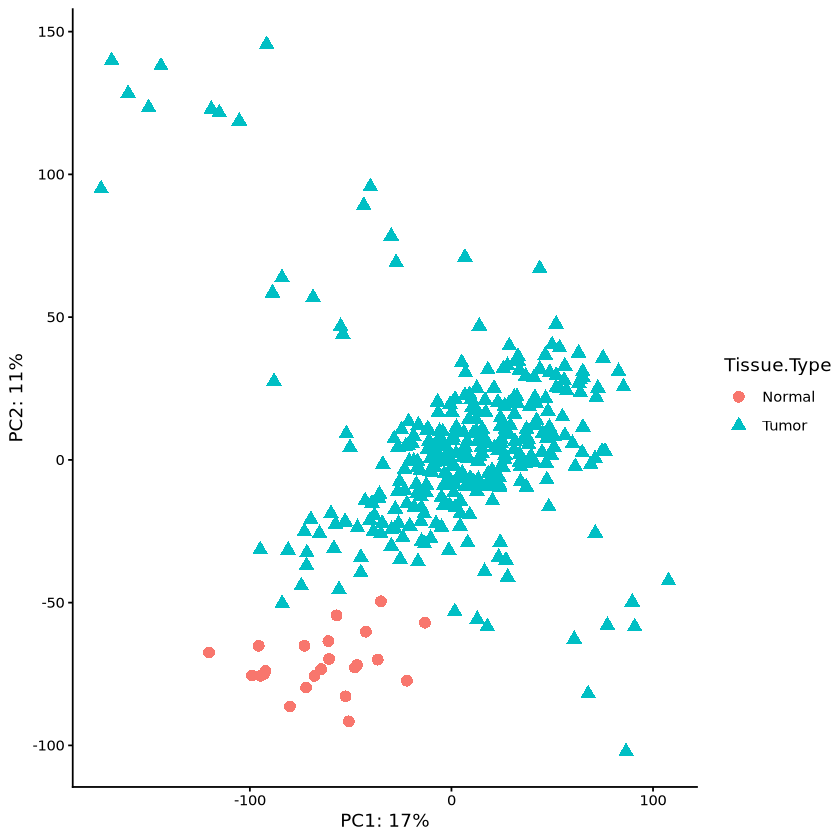

In [9]:
pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  rna_metadata
)

ggplot(pca_df, aes(PC1, PC2,
                   color = Tissue.Type,
                   shape = Tissue.Type)) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [10]:
vsd_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)
pca_mirna <- prcomp(t(assay(vsd_mirna)), scale. = FALSE)
percentVar <- (pca_mirna$sdev^2) / sum(pca_mirna$sdev^2)

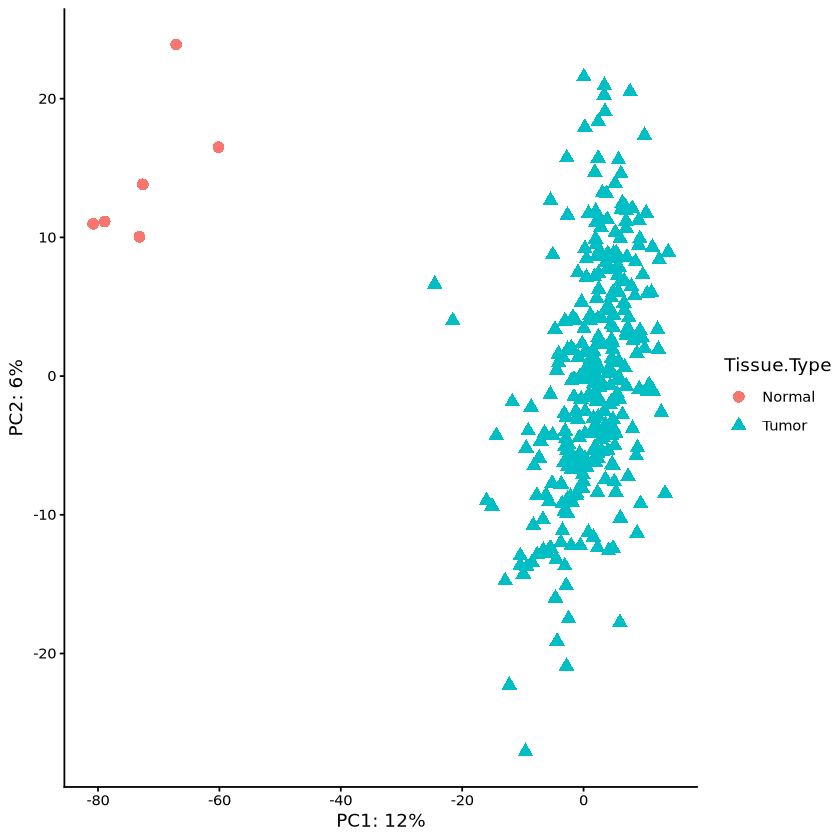

In [11]:
pca_df_mirna <- data.frame(
  PC1 = pca_mirna$x[,1],
  PC2 = pca_mirna$x[,2],
  mirna_metadata
)

ggplot(pca_df_mirna, aes(PC1, PC2,
                   color = Tissue.Type,
                   shape = Tissue.Type)) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [12]:
rna_network_dir <- "../rna_pooled_tmm0.4"

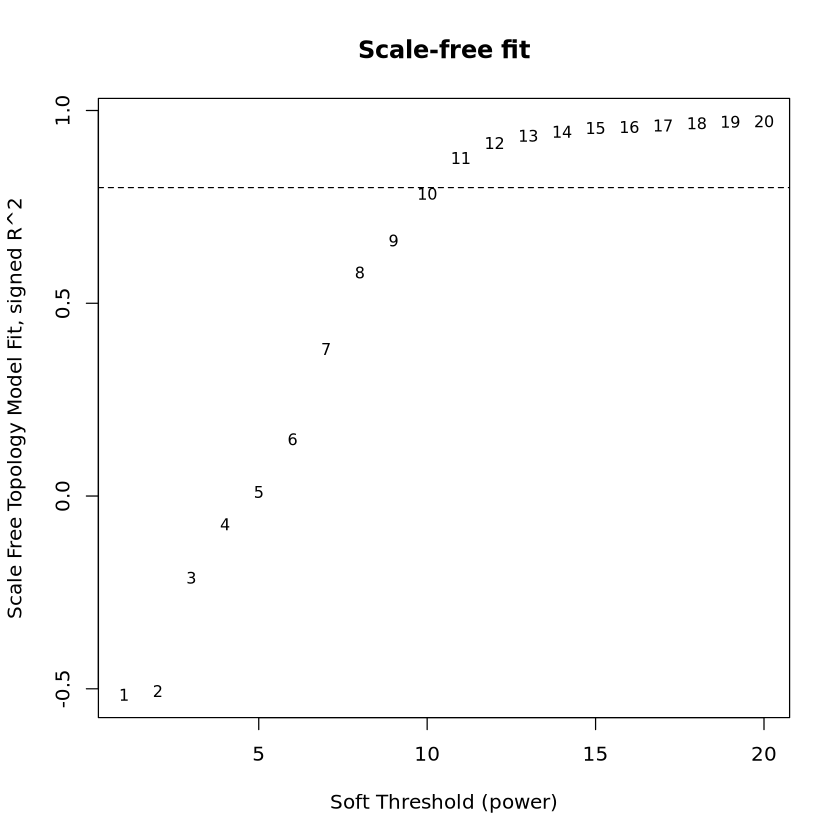

In [13]:
# Load the pre-computed WGCNA modules of RNA pooled
sft <- readRDS(paste(rna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

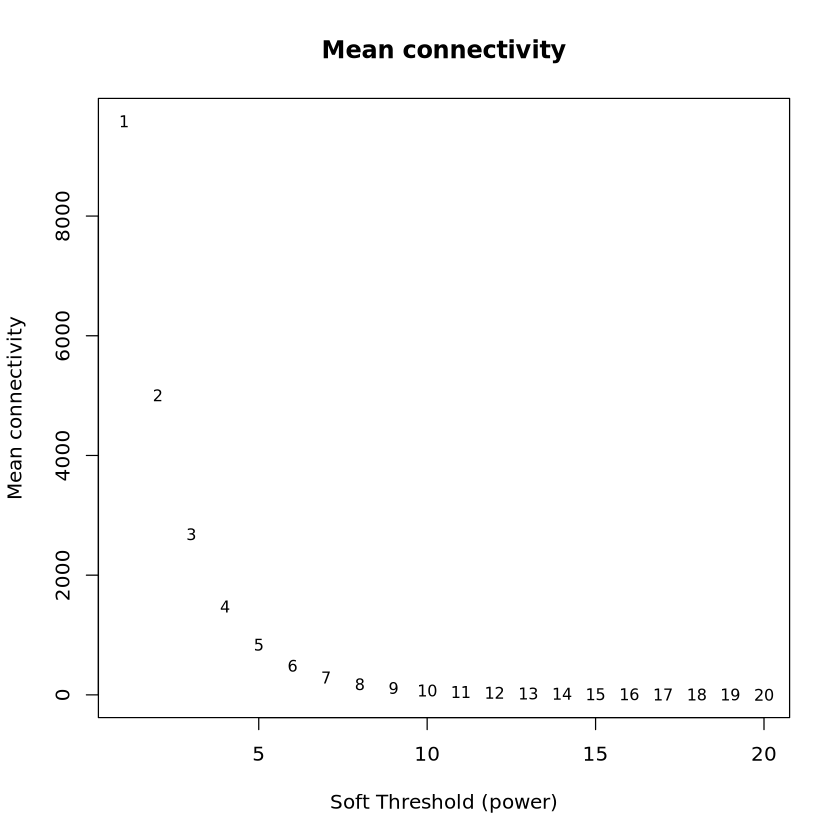

In [14]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

In [15]:
net <- readRDS(paste(rna_network_dir, "/blockwise_net.rds", sep=""))
rna_net <- net
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))

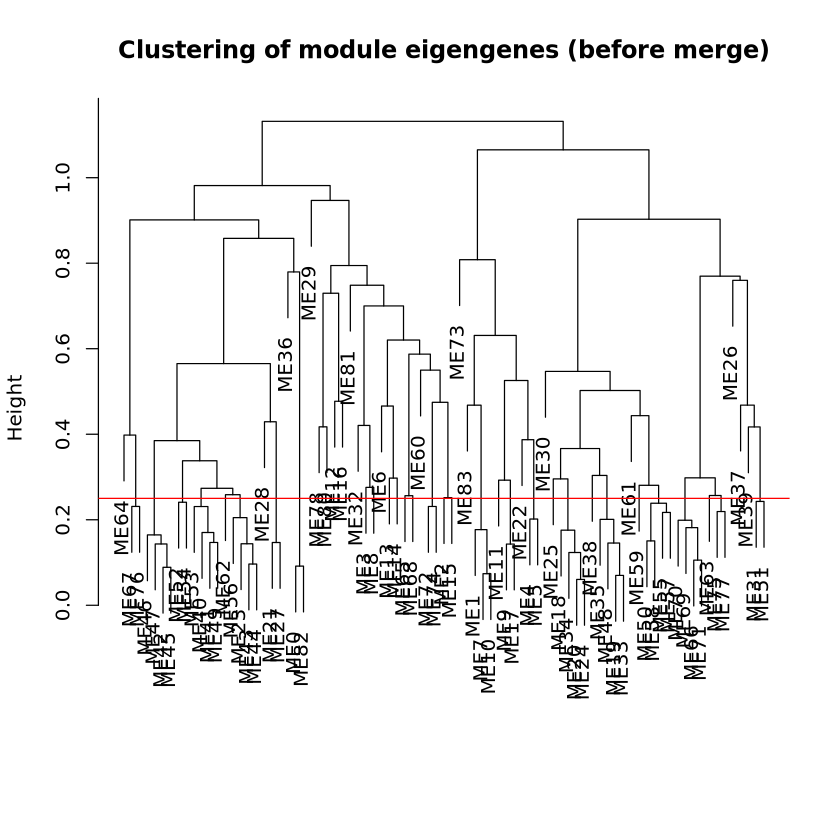

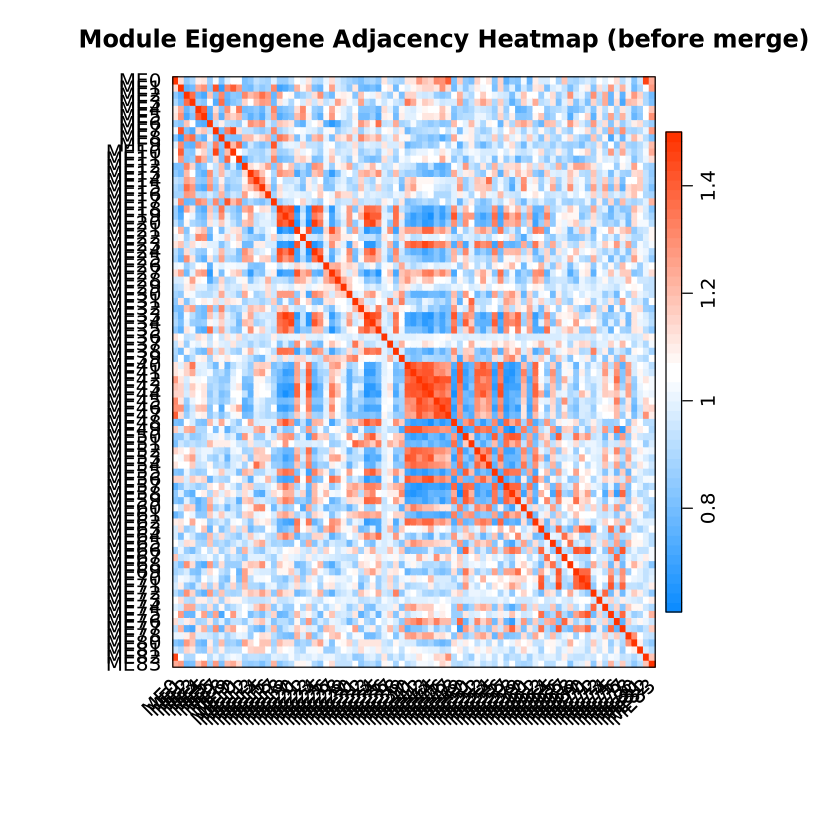

In [16]:
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.25, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

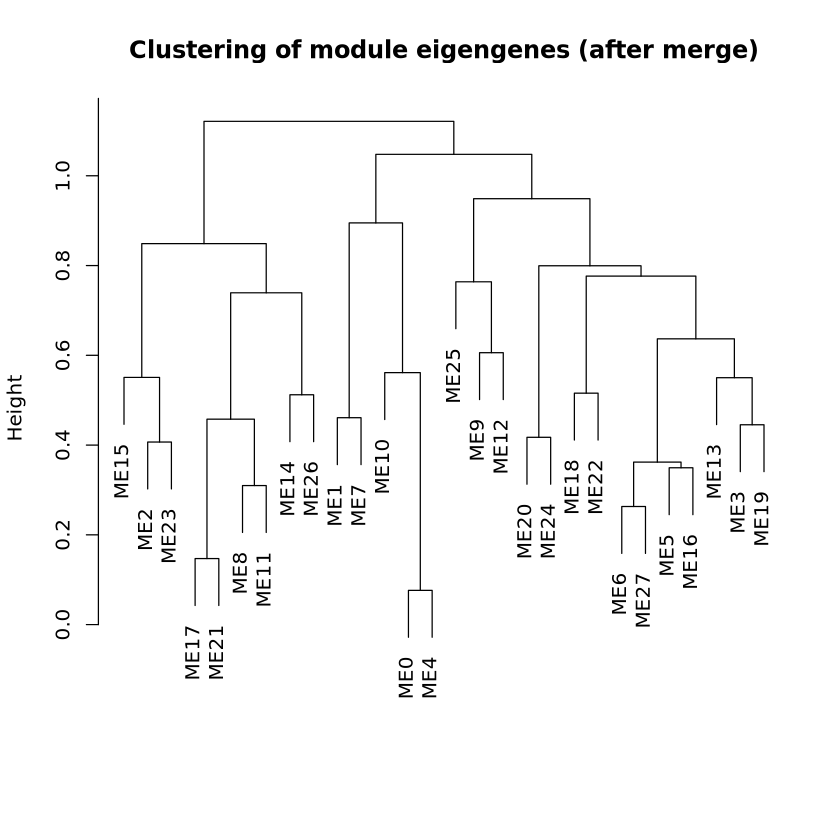

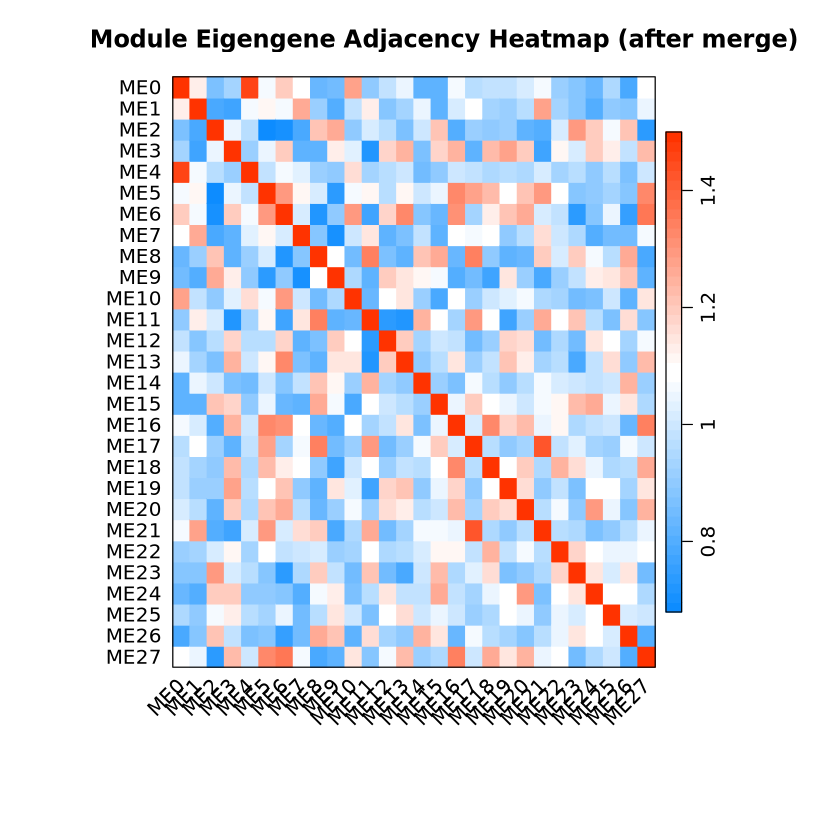

In [17]:
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

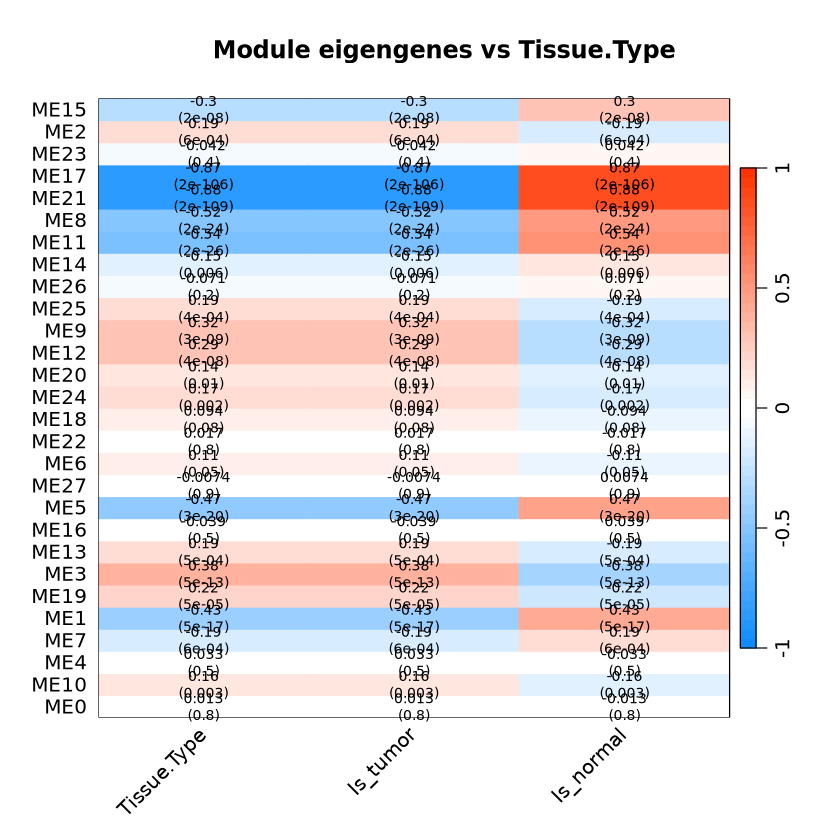

In [18]:
# Load
MEs    <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(rna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY Tissue.Type
if (!("Tissue.Type" %in% colnames(traits))) stop("Column 'Tissue.Type' not found in traits.")

trait_pheno <- traits[, "Tissue.Type", drop = FALSE]

# Convert Tissue.Type to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno$Tissue.Type)) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno$Tissue.Type))
  if (length(lev) != 2) {
    stop(paste0(
      "Tissue.Type must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev)
  trait_pheno$Tissue.Type <- ifelse(as.character(trait_pheno$Tissue.Type) == lev[2], 1, 0)
}

# add new columns: Is_tumor and Is_normal
trait_pheno$Is_tumor <- ifelse(trait_pheno$Tissue.Type == 1, 1, 0)
trait_pheno$Is_normal <- ifelse(trait_pheno$Tissue.Type == 1, 0, 1)

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = c("Tissue.Type", "Is_tumor", "Is_normal"),
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = "Module eigengenes vs Tissue.Type"
)

In [19]:
rna_ME_traitcor <- MEtraitCor
write.csv(rna_ME_traitcor, file = paste(rna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [20]:
net <- readRDS(paste(rna_network_dir, "/blockwise_net.rds", sep=""))
rna_net <- net

In [21]:
mirna_network_dir <- "../newmirna_pooled"

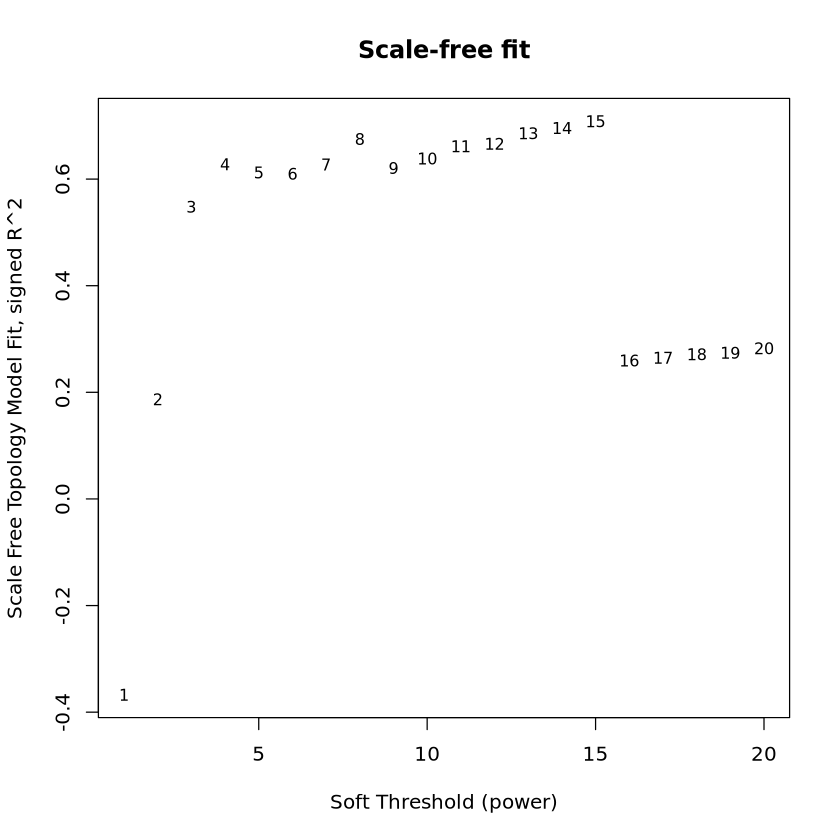

In [22]:
# Load the pre-computed WGCNA modules of miRNA pooled
sft <- readRDS(paste(mirna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

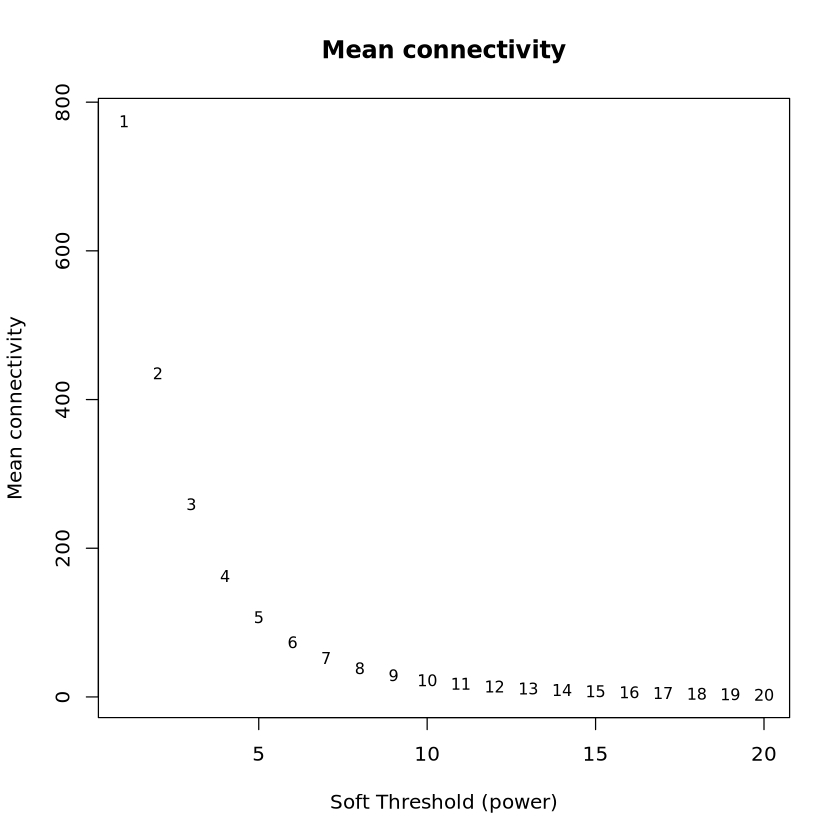

In [23]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

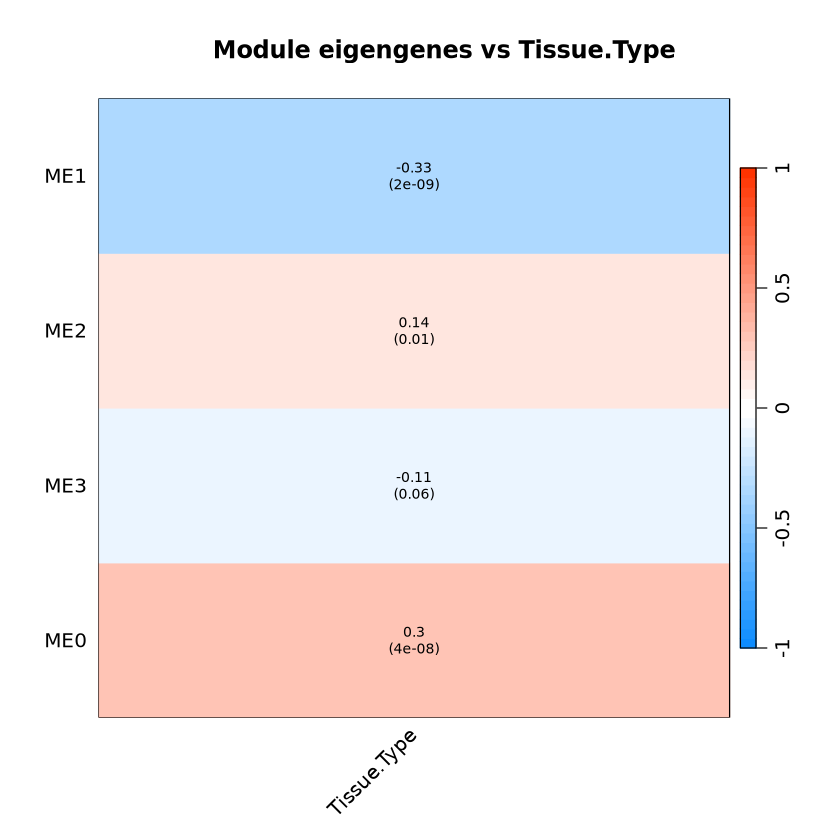

In [24]:
# Load
MEs    <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(mirna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY Tissue.Type
if (!("Tissue.Type" %in% colnames(traits))) stop("Column 'Tissue.Type' not found in traits.")

trait_pheno <- traits[, "Tissue.Type", drop = FALSE]

# Convert Tissue.Type to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno$Tissue.Type)) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno$Tissue.Type))
  if (length(lev) != 2) {
    stop(paste0(
      "Tissue.Type must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev)
  trait_pheno$Tissue.Type <- ifelse(as.character(trait_pheno$Tissue.Type) == lev[2], 1, 0)
}

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = "Tissue.Type",
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = "Module eigengenes vs Tissue.Type"
)

In [25]:
miRNA_traitCor <- MEtraitCor
write.csv(MEtraitCor, file = paste(mirna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [26]:
net <- readRDS(paste(mirna_network_dir, "/blockwise_net.rds", sep=""))
mirna_net <- net

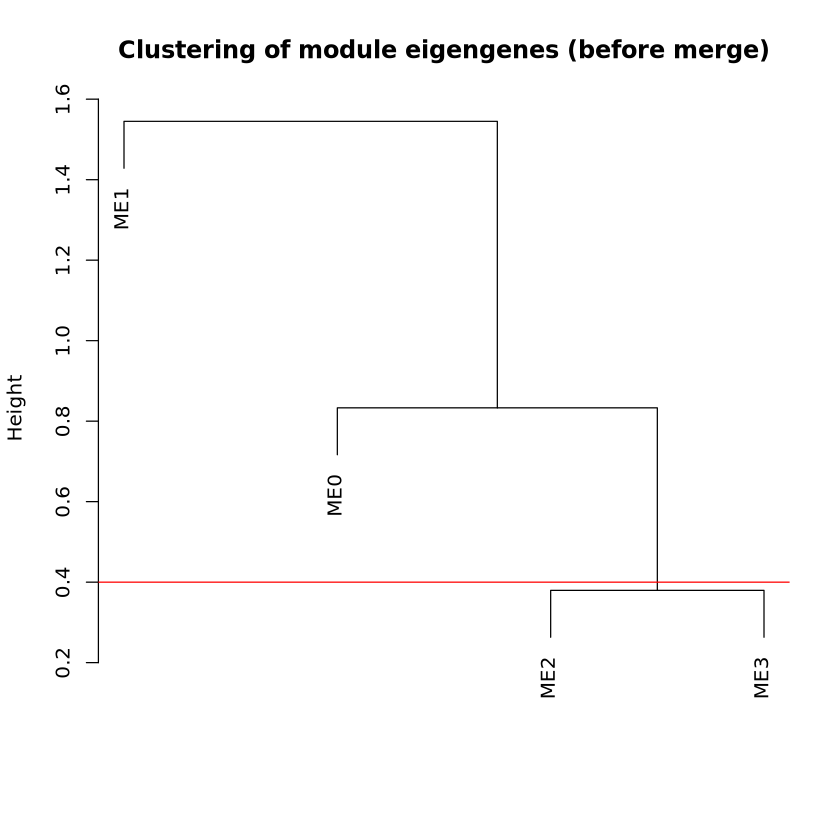

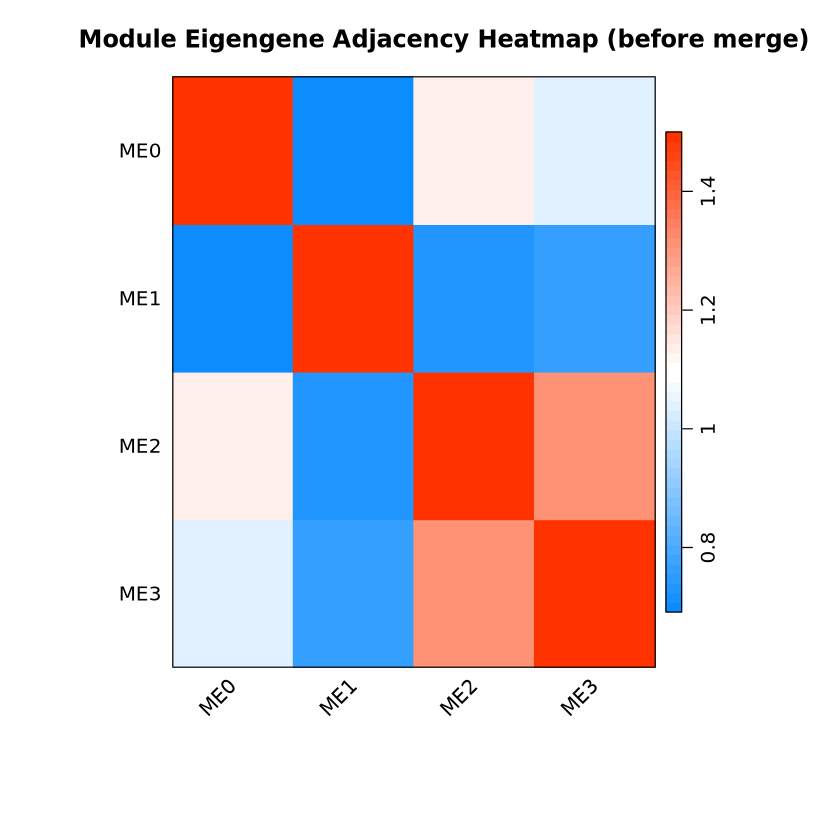

In [27]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.4, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

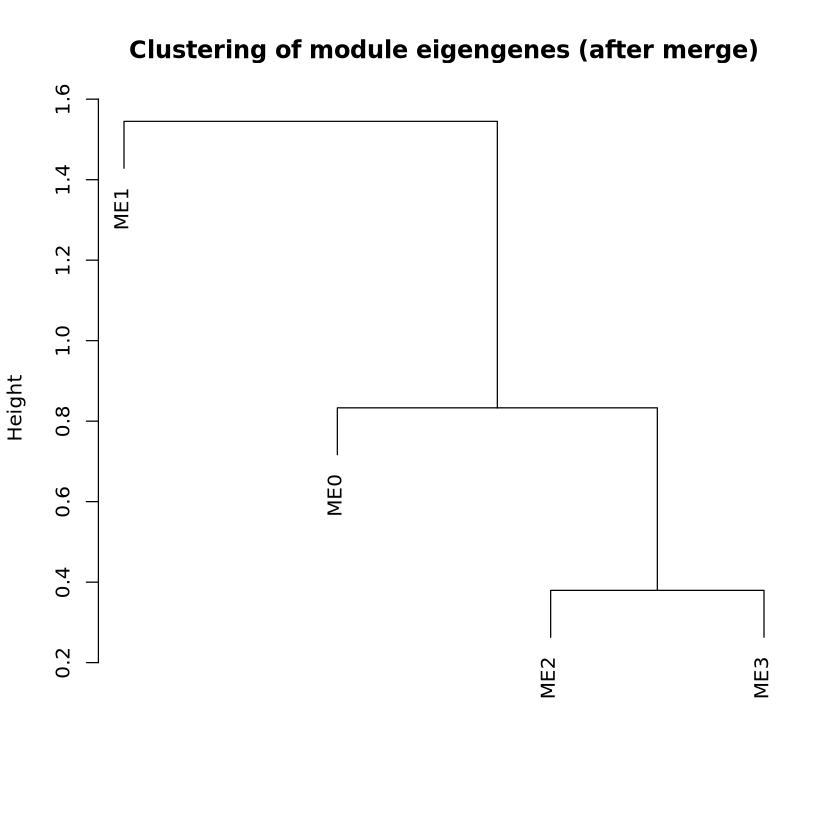

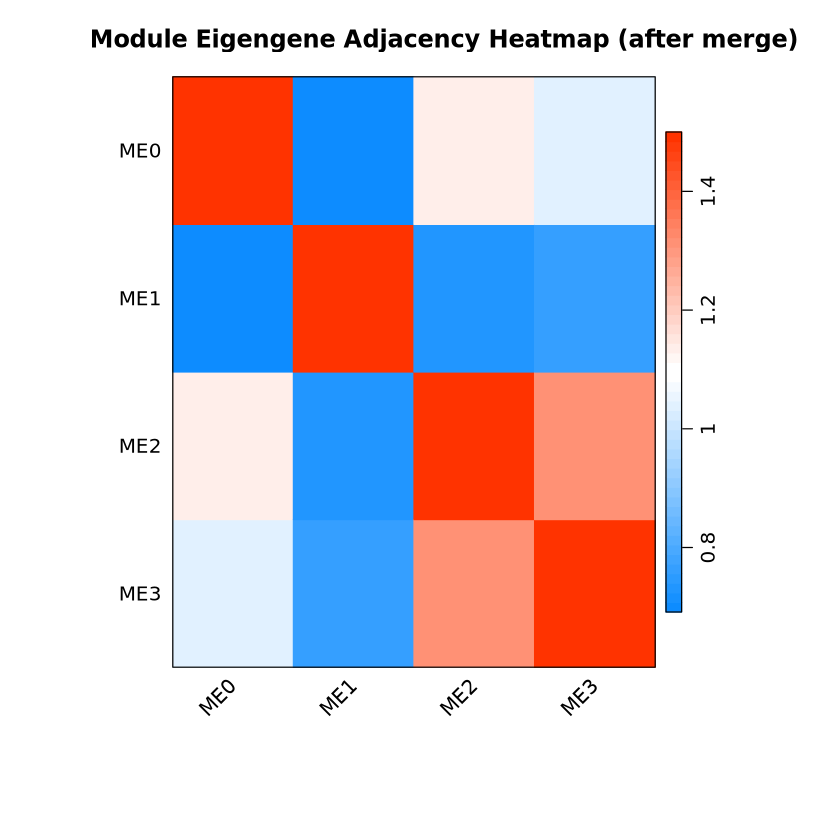

In [28]:
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [29]:
filter_genes <- function(df, kme_limit, kme_p_limit, gs_limit, gs_p_limit) {
  
  # 1. Identificar automáticamente las columnas kME (los valores de correlación)
  # Buscamos columnas que empiecen con kME_ME y terminen en un número (no en _P)
  cols_kme <- grep("^kME_ME\\d+$", colnames(df), value = TRUE)
  
  message("Módulos detectados para el filtro: ", paste(cols_kme, collapse = ", "))

  # 3. Aplicar el filtro dinámico
  df_filtrado <- df %>%
    # Filtro de Fenotipo (GS)
    filter(abs(GS_Tissue.Type) > gs_limit & GS_Tissue.Type < gs_p_limit) %>%
    
    # Filtro de Membresía (kME) horizontal
    rowwise() %>%
    filter({
      # Verificamos si existe algún par (kME, kME_P) que cumpla la condición
      any(sapply(cols_kme, function(col) {
        p_col <- paste0(col, "_P")
        
        # Validación de seguridad: verificar que la columna _P exista en el df
        if (!p_col %in% colnames(df)) return(FALSE)
        
        val_kme <- get(col)
        val_p   <- get(p_col)
        
        # El gen debe cumplir ambos criterios en el MISMO módulo
        !is.na(val_kme) && abs(val_kme) > kme_limit && 
        !is.na(val_p)   && val_p < kme_p_limit
      }))
    }) %>%
    ungroup()

  return(as.data.frame(df_filtrado))
}

In [30]:
MEs_rna <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
MEs_mirna <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))

In [31]:
# get list modules with |r| > thresh with Tissue.Type from miRNA_traitCor and rna_ME_traitcor #miRNA_traitCor #rna_ME_traitcor

cor_thresh <- 0
MEs_rna <- rna_ME_traitcor[which(abs(rna_ME_traitcor[,1]) > cor_thresh), , drop=FALSE]
MEs_mirna <- miRNA_traitCor[which(abs(miRNA_traitCor[,1]) > cor_thresh), , drop=FALSE]

# remove ME0 from MEs_rna and MEs_mirna
MEs_rna <- MEs_rna[!rownames(MEs_rna) %in% "ME0", , drop=FALSE]
MEs_mirna <- MEs_mirna[!rownames(MEs_mirna) %in% "ME0", , drop=FALSE]

# REMOVE ME from the name
rownames(MEs_rna) <- gsub("ME", "", rownames(MEs_rna))
rownames(MEs_mirna) <- gsub("ME", "", rownames(MEs_mirna))

MEs_rna <- as.data.frame(MEs_rna)
MEs_rna$moduleNumber <- rownames(MEs_rna)

MEs_mirna <- as.data.frame(MEs_mirna)
MEs_mirna$moduleNumber <- rownames(MEs_mirna)

# hasta aca se tienen los listados de modules significativos para rna y miRNA en moduleNumber

# reemplazar cada moduleNumber por kME_ME_number
MEs_rna$kme_ME_number <- paste("kME_ME", MEs_rna$moduleNumber, sep="")
MEs_mirna$kme_ME_number <- paste("kME_ME", MEs_mirna$moduleNumber, sep="")

In [32]:
kMEs_keep_rna <- MEs_rna$kme_ME_number
KMEs_P_keep_rna <- paste(kMEs_keep_rna, "_P", sep="")
GS_keep_rna <- c("GS_Tissue.Type", "GS_Tissue.Type_P")

kMEs_keep_mirna <- MEs_mirna$kme_ME_number
KMEs_P_keep_mirna <- paste(kMEs_keep_mirna, "_P", sep="")
GS_keep_mirna <- c("GS_Tissue.Type", "GS_Tissue.Type_P")

In [33]:
# kME tables
kme_table_rna <- readRDS(paste(rna_network_dir, "/kME_table.rds", sep=""))
kme_table_rna_P <- readRDS(paste(rna_network_dir, "/kME_P_table.rds", sep=""))

# GS tables
GS_table_rna <- readRDS(paste(rna_network_dir, "/GS_table.rds", sep=""))
GS_table_rna_P <- readRDS(paste(rna_network_dir, "/GS_P_table.rds", sep=""))

# fuse rna tables
rna_table <- cbind(kme_table_rna, kme_table_rna_P, GS_table_rna, GS_table_rna_P)
# drop gene column
rna_table <- rna_table[, c(kMEs_keep_rna, KMEs_P_keep_rna, GS_keep_rna)]
rna_table$gene <- rownames(rna_table)

In [34]:
selected_rna <- filter_genes(rna_table, kme_limit = 0.4, kme_p_limit = 1e-05,gs_limit = 0.4, gs_p_limit = 1e-02)

Módulos detectados para el filtro: kME_ME15, kME_ME2, kME_ME23, kME_ME17, kME_ME21, kME_ME8, kME_ME11, kME_ME14, kME_ME26, kME_ME25, kME_ME9, kME_ME12, kME_ME20, kME_ME24, kME_ME18, kME_ME22, kME_ME6, kME_ME27, kME_ME5, kME_ME16, kME_ME13, kME_ME3, kME_ME19, kME_ME1, kME_ME7, kME_ME4, kME_ME10



In [35]:
# kME tables for miRNA
kme_table_mirna <- readRDS(paste(mirna_network_dir, "/kME_table.rds", sep=""))
kme_table_mirna_P <- readRDS(paste(mirna_network_dir, "/kME_P_table.rds", sep=""))

# GS tables for miRNA
GS_table_mirna <- readRDS(paste(mirna_network_dir, "/GS_table.rds", sep=""))
GS_table_mirna_P <- readRDS(paste(mirna_network_dir, "/GS_P_table.rds", sep=""))

# fuse mirna tables
mirna_table <- cbind(kme_table_mirna, kme_table_mirna_P, GS_table_mirna, GS_table_mirna_P)
mirna_table <- mirna_table[, c(kMEs_keep_mirna, KMEs_P_keep_mirna, GS_keep_mirna)]
mirna_table$gene <- rownames(mirna_table)

In [36]:
selected_mirna <- filter_genes(mirna_table, kme_limit = 0, kme_p_limit = 1, gs_limit = 0.4, gs_p_limit = 1e-02)

Módulos detectados para el filtro: kME_ME1, kME_ME2, kME_ME3



In [37]:
# load ENCORI dataframe
encori_filtered <- read_tsv("../../ENCORI_hg38_miRNA-mRNA_FILTERED.tsv")

Rows: 219690 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (9): miRNAid, miRNAname, geneID, geneName, geneType, chromosome, strand...
dbl (18): narrowStart, narrowEnd, broadStart, broadEnd, clipExpNum, degraExp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
genes_selected_rna_noversion <- gsub("\\.\\d+$", "", selected_rna$gene)

In [39]:
edges_selected <- encori_filtered %>%
  filter(
    geneID %in% genes_selected_rna_noversion &
    miRNAid %in% selected_mirna$gene
  )
dim(edges_selected)

[1] 734  27

In [40]:
unique_encori <- edges_selected %>%
  group_by(miRNAid, geneID) %>%
  summarise(
    weight = n(), # Cuenta cuántas veces aparece el par
    .groups = 'drop'
  )
dim(unique_encori)

[1] 604   3

In [41]:
rownames(df_rna) <- gsub("\\.\\d+$", "", rownames(df_rna))
df_rna <- as.data.frame(df_rna)
df_mirna <- as.data.frame(df_mirna)

In [42]:
# 1. Preparar la anotación de Genes
anotacion_genes <- data.frame(
  NodeID = rownames(df_rna),
  Category = df_rna$Category,
  NodeType = "Gene"  # Indicamos que estos son genes
)
# 2. Preparar la anotación de miRNAs
anotacion_mirnas <- data.frame(
  NodeID = rownames(df_mirna),
  Category = df_mirna$Category,
  NodeType = "miRNA"  # Indicamos que estos son miRNAs
)
# 3. Unir ambas tablas en una sola (Master Node Table)
master_node_table <- bind_rows(anotacion_genes, anotacion_mirnas)
# 4. Eliminar duplicados por si acaso
master_node_table <- master_node_table %>% distinct(NodeID, .keep_all = TRUE)
# 5. Guardar para Cytoscape
write.csv(master_node_table, "anotacion_nodos_cytoscape.csv", row.names = FALSE)

In [43]:
dim(unique_encori)
write.table(unique_encori, file="ENCORI_filtered_edges_selected_modules_WHITE.tsv", sep="\t", quote=FALSE, row.names=FALSE, col.names = TRUE)

[1] 604   3